# v1 baseline, re-run on the corrected pipeline

v1 is the pre-nitro-zone design: location and count, two XGBoost action models,
and a player metric that averages the value of whichever action the hitter
actually took. It scored YoY R² = 0.57 historically.

That historical number cannot be compared with anything the rebuild produces.
It came from a data path that included overseas games and pitchers batting,
refit run-value tables per season, mapped `field_error` onto `field_out`, used
a single 2022→2023 pair, and had no 2026 harmonization. This notebook runs
v1's **design** on **correct data**, which is what makes it a usable baseline.

Spec: `IMPROVEMENT_PLAN.md` → "Baselines to reproduce". Retired notebooks are
in git history at `fa48b14`.

In [1]:
import sys; sys.path.insert(0, '..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src import data as D
from src import evaluate as E
from src.baselines import fit_v1, predict_chosen, V1_FEATURES, V1_TAKE_PARAMS, V1_SWING_PARAMS

pd.set_option('display.width', 130)
sns.set_theme(style='whitegrid')
PALETTE = ['#FFB000', '#648FFF', '#785EF0', '#DC267F', '#FE6100', '#3D1EB2']

TRAIN = [2021, 2022, 2023, 2024]     # plan §0.1.3 Model A
SEASONS = range(2021, 2027)
print('features:', V1_FEATURES)

features: ['plate_x_mid', 'plate_z_mid', 'count']


## Data

Harmonized location, pitcher-batting filter, one run-value table fitted on the
training seasons. `plate_x_mid`/`plate_z_mid` are the harmonized coordinates —
harmonization is a data correction, so it applies. Batter-frame mirroring and
zone normalization are *design* changes belonging to Track A2 and deliberately
do not appear here.

In [2]:
df = D.drop_pitchers_batting(D.load_seasons(SEASONS, verbose=True))
rv = D.run_value_table(df, years=TRAIN)
df = D.apply_run_value(df, rv, name='target').dropna(subset=['target', 'plate_x_mid', 'plate_z_mid'])
print(f'\nanalysis frame: {len(df):,} rows | run-value cells: {len(rv)} | target nulls: {df.target.isna().sum()}')

4,237,650 rows in
  -   13,872  non-decision (auto ball/strike)
  -    2,057  no tracked location
  -       44  no trajectory
  -       31  no delta_run_exp
  -       53  in-play with unmapped event
 4,221,593  kept



analysis frame: 4,186,695 rows | run-value cells: 132 | target nulls: 0


## Fit and score

In [3]:
models = fit_v1(df[df.season.isin(TRAIN)])
df = predict_chosen(df, models)
print(f'take : {V1_TAKE_PARAMS}')
print(f'swing: {V1_SWING_PARAMS}')
df[['season', 'swing', 'target', 'y_pred']].head()

take : {'objective': 'reg:squarederror', 'eval_metric': 'rmse', 'random_state': 1126, 'tree_method': 'hist', 'max_depth': 8, 'learning_rate': 0.03}
swing: {'objective': 'reg:squarederror', 'eval_metric': 'rmse', 'random_state': 1126, 'tree_method': 'hist', 'max_depth': 7, 'learning_rate': 0.01}


,season,swing,target,y_pred
0,2021,True,-0.185117,0.002915
1,2021,True,-0.063833,-0.021234
2,2021,True,-0.049699,0.008847
3,2021,False,0.036675,0.083931
4,2021,True,-0.296136,-0.007861


## Sub-model performance

Always reported against a count-only lookup, never on its own. The target is
the mean run value of an (outcome, count) pair, so a model given only the count
already reproduces most of it — that is the floor, and the gap above it is what
location actually buys.

An absolute RMSE is close to meaningless here. A take can only end three ways,
and at a fixed count those three run values sit within a few hundredths of a
run of each other, so *any* take model will post a small RMSE. Swings scatter
across seven outcomes spanning nearly two runs, so any swing model will post a
large one. Comparing the two numbers directly would say only that takes are
less variable than swings.

In [4]:
rows = []
for label, seasons in [('train 2021-24', TRAIN), ('2025', [2025]), ('2026 (ABS)', [2026])]:
    r = E.rmse_vs_count_baseline(df[df.season.isin(seasons)], models)
    r['split'] = label
    rows.append(r.reset_index())
pd.concat(rows).set_index(['split', 'action']).round(4)

n    rmse  rmse_count_only  improvement_%
split         action                                                 
train 2021-24 take    1470483  0.0432           0.0766        43.5649
              swing   1341915  0.2988           0.3014         0.8474
2025          take     368453  0.0438           0.0767        42.8722
              swing    336956  0.2987           0.3010         0.7698
2026 (ABS)    take     350127  0.0424           0.0769        44.8311
              swing    318761  0.2969           0.2991         0.7411

**The swing model is the story.** Location and count buy ~44% over a count-only
lookup for takes, and under 1% for swings. Knowing where a pitch was tells you
almost nothing about what happens when a hitter swings at it — which is the
quantified case for Track B's event decomposition, and matches Salorio's
retrospective conclusion that swing value is the hard half.

## Player metric and reliability

In [5]:
scores = E.player_metric(df, 'y_pred')
print('qualified hitters (>=500 pitches) per season:')
print(scores.groupby('season').size().to_string())
E.yoy_reliability(scores, train_seasons=TRAIN).round(3)

qualified hitters (>=500 pitches) per season:
season
2021    437
2022    435
2023    432
2024    425
2025    419
2026    423


,hitters,r,r2,in_sample
pair,,,,
2021->2022,330,0.724,0.524,True
2022->2023,325,0.761,0.578,True
2023->2024,332,0.745,0.555,True
2024->2025,326,0.711,0.506,False
2025->2026,322,0.655,0.430,False


In [6]:
E.split_half(df, 'y_pred').round(3)

,hitters,r_half,r_spearman_brown
season,,,
2021,419,0.591,0.743
2022,425,0.617,0.763
2023,421,0.663,0.797
2024,417,0.567,0.724
2025,405,0.616,0.762
2026,411,0.553,0.712


## Validity

Two questions reliability cannot answer: is the metric measuring the pitches a
hitter was thrown rather than his decisions, and does it predict anything.

In [7]:
E.zone_pct_correlation(df, scores).round(3)

,hitters,r,variance_explained_%,zone_pct_std
season,,,,
2021,437,0.073,0.537,0.021
2022,435,0.102,1.036,0.022
2023,432,0.056,0.308,0.024
2024,425,0.100,0.996,0.022
2025,419,0.026,0.065,0.024
2026,423,0.108,1.172,0.020


In [8]:
E.predictive_validity(df, scores).round(3)

,hitters,r_raw,r_partial
pair,,,
2021->2022,330,0.258,0.047
2022->2023,325,0.329,0.171
2023->2024,332,0.288,0.098
2024->2025,326,0.317,0.135
2025->2026,322,0.139,-0.071


## Sanity checks

Reliability statistics cannot tell a well-behaved metric from a
consistently-wrong one: a metric measuring the wrong quantity can be perfectly
stable year to year. The leaderboard can. Hitters at the extremes of plate
discipline are known independently of any model, so if the ordering disagrees
with reputation — patient hitters low, free swingers high — something is wrong
no matter how good the reliability looks. Check it before trusting any number
above.

In [9]:
try:
    from pybaseball import playerid_reverse_lookup
    s26 = scores[scores.season == 2026].copy()
    names = playerid_reverse_lookup(s26.batter.tolist())
    names['name'] = (names.name_first + ' ' + names.name_last).str.title()
    s26 = s26.merge(names[['key_mlbam', 'name']], left_on='batter', right_on='key_mlbam')
    cols = ['name', 'pitches', 'decision_value']
    print('TOP 10, 2026'); display(s26.nlargest(10, 'decision_value')[cols].round(1))
    print('BOTTOM 10, 2026'); display(s26.nsmallest(10, 'decision_value')[cols].round(1))
except Exception as exc:
    print(f'name lookup unavailable ({exc}); showing ids')
    display(scores[scores.season == 2026].nlargest(10, 'decision_value').round(1))

Gathering player lookup table. This may take a moment.


TOP 10, 2026


,name,pitches,decision_value
144,Juan Soto,1713,125.7
249,Jorbit Vivas,1214,121.4
89,Gleyber Torres,1652,121.4
121,Kyle Tucker,2334,121.1
370,Braden Montgomery,1280,120.9
46,Corey Seager,1450,120.8
170,Jj Bleday,2017,120.2
408,Kevin Mcgonigle,2667,120.1
248,Miguel Vargas,2613,119.9
108,Ronald Acuña,1757,119.5


BOTTOM 10, 2026


,name,pitches,decision_value
30,Javier Báez,623,57.7
64,Edmundo Sosa,867,67.5
33,Trevor Story,860,69.9
62,Jose Trevino,519,73.0
279,Noelvi Marte,761,74.7
281,Angel Martínez,1401,75.0
212,Michael Harris,2087,76.3
378,Jose Fernandez,798,79.4
325,Christian Encarnacion-Strand,691,79.9
342,Daniel Susac,590,79.9


Text(0.5, 0.98, 'v1 scored surface — catcher frame')

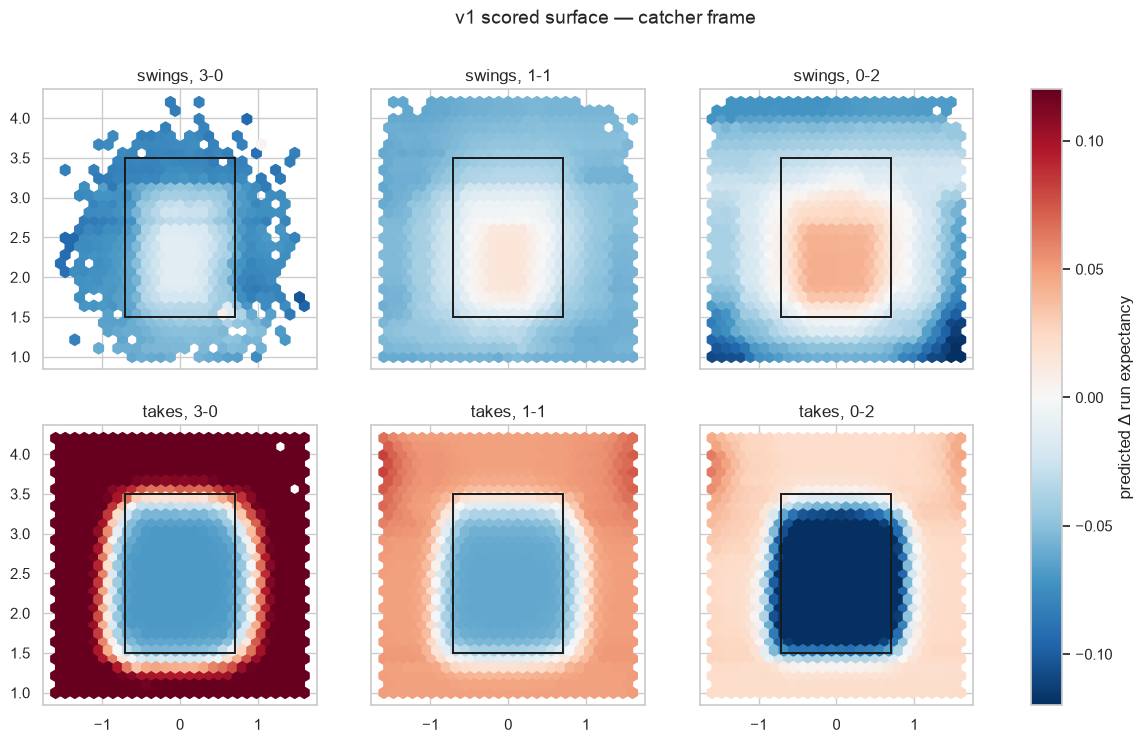

In [10]:
# The scored surface, by count. 3-0 and 0-2 must look materially different, and
# the swing surface must be positive over the plate and negative well outside.
fig, ax = plt.subplots(2, 3, figsize=(15, 8), sharex=True, sharey=True)
for row, (swung, lbl) in enumerate([(True, 'swings'), (False, 'takes')]):
    for col, cnt in enumerate(['3-0', '1-1', '0-2']):
        g = df[(df.swing == swung) & (df['count'].astype(str) == cnt)]
        hb = ax[row, col].hexbin(g.plate_x_mid, g.plate_z_mid, C=g.y_pred, gridsize=26,
                                 extent=[-1.6, 1.6, 1.0, 4.2], cmap='RdBu_r', vmin=-0.12, vmax=0.12)
        ax[row, col].add_patch(plt.Rectangle((-0.708, 1.5), 1.416, 2.0, fill=False, color='k', lw=1.4))
        ax[row, col].set_title(f'{lbl}, {cnt}')
fig.colorbar(hb, ax=ax, label='predicted Δ run expectancy')
fig.suptitle('v1 scored surface — catcher frame', y=0.98, fontsize=14)

## Findings

**The reimplementation tracks v1.** The 2022→2023 pair — the only one the
historical figure covered — comes in at R² ≈ 0.58 against the published 0.57,
on a pipeline that differs in every way listed at the top. That agreement is
the evidence that this is v1's design rather than something new wearing its
name.

**Reliable.** YoY R² runs 0.43–0.58 and split-half reliability is ≈ 0.75. The
metric measures something stable about a hitter.

**Not confounded by pitch mix, contrary to expectation.** Zone% explains only
0.1–1.2% of the metric's variance, against the ~23% that retired SOTO. The
standing worry that "a hitter who sees more hittable pitches scores better"
does not show up in v1 at this magnitude. That makes v1 a stronger baseline
than assumed, and raises the bar for Track A and B.

**But barely valid.** Controlling for current production, season-*t* decision
value predicts season-*t+1* production at a partial r of ≈ 0.08, and the
2025→2026 pair is slightly negative. v1 is reliable without being useful: it
measures *something* about a hitter consistently, but that something adds
almost nothing to knowing how he already hit. This is the gap the rebuild has
to close, and the number to beat.

**Where the weakness sits.** The swing model improves on a count-only lookup by
under 1%. v1's decision value is therefore driven almost entirely by its take
model, which is really a called-strike probability in disguise. Track B's event
decomposition targets exactly this.

In [11]:
res = E.harness(df, models, label='v1 re-run', train_seasons=TRAIN)
pd.Series(res['summary']).to_frame('v1 re-run')

,v1 re-run
variant,v1 re-run
take RMSE vs count-only,0.0432 / 0.0767
swing RMSE vs count-only,0.2985 / 0.3010
split-half r,0.75
YoY R2 (mean),0.519
Zone% |r|,0.077
next-season r (partial),0.076
